In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import scipy as sp

def calc_SE(n, s_dev):
    return s_dev / np.sqrt(n)

def calc_t_df(confidence_level, df):
    return t.interval(confidence_level, df)

def confidence_interval(n, mean, s_dev, confidence_level, decimals=3):
    df = n - 1
    SE = calc_SE(n, s_dev)
    t_df = calc_t_df(confidence_level, df)[1]
    low, high = mean-(t_df*SE), mean+(t_df*SE)
    print(f"({round(low, decimals)}, {round(high, decimals)})")

def t_score(sample_mean, null_value, SE):
    return (sample_mean - null_value) / SE

### Standard error
$$
SE = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}
$$
where $s$ is the sample standard deviation.
### Confidence Interval
$$\begin{align}
\bar{x} \pm t^*_{df}\times\frac{s}{\sqrt{n}}
\end{align}$$
where $t^*_{df}$ is a cutoff obtained based on teh confidence level and the *t*-distribtuion with *df* degrees of freedom.
### T-score
$$
T = \frac{\bar{x} - x_{null}}{SE}
$$

In [4]:
# Cumulative distribution function
print(t.cdf(-2.1, 18))  # area under the curve less than t=-2.1 for df=18
print(round(t.sf(1.65, 20), 4))    # area under the curve before t=1.65 with df=4
print(2 * t.cdf(-3, 2))

# Percent point function
print()
print(t.ppf(0.025, 18))
print(calc_t_df(0.95, 18))
print(t.interval(0.95, 18)[1])
# sample
print()
print(confidence_interval(19, 4.4, 2.3, 0.95, decimals=2))

# p-value from T-score
print(t.cdf(0, 99))
print(t.pdf(0, 99))

0.025045202854784173
0.0573
0.09546596626670913

-2.10092204024096
(np.float64(-2.10092204024096), np.float64(2.10092204024096))
2.10092204024096

(3.29, 5.51)
None
0.5
0.3979361384240588


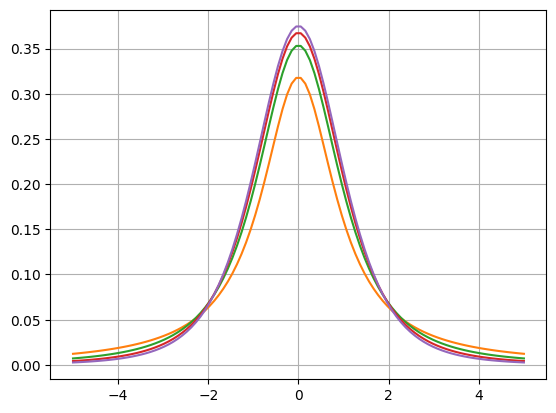

In [10]:
x = np.linspace(-5, 5, 100)
pdf = t.pdf(x, 1)

for i in range(5):
    plt.plot(x, t.pdf(x,i))

plt.grid()
plt.show()

# Probset

## PDF
$$
P(t, v) = \frac{\Gamma\left( \frac{v+1}{2} \right)}{\sqrt{\pi v} ~\Gamma\left( \frac{v}{2} \right)} \left( 1 + \frac{t^2}{v} \right)^{-\frac{v+1}{2}}
$$

$$
F(t, v) = \frac{1}{2} + t~\Gamma\left( \frac{v+1}{2} \right) \frac{G\left(\frac{1}{2}, \frac{v+1}{2}, \frac{3}{2}, -\frac{t^2}{v}\right)}{\sqrt{\pi v}~\Gamma\left( \frac{v}{2} \right)}
$$

In [ ]:
import numpy as np
import scipy.special as sp
from scipy.stats import t

def CDF(t, v):
    return 0.5 + t*sp.gamma((v+1)*0.5) * sp.hyp2f1(0.5, (v+1)*0.5, 1.5, -t**2/v) / (np.sqrt(np.pi * v) * sp.gamma(v/2))

def p_val(t, v):
    return 2 * (1 - CDF(t, v))

In [62]:
print(p_val(2.6, 100))
#print(p_val(2.7, 100))
print(2 * t.sf(2.6, 100))

0.010733783394784036
0.010733783394738919


# F-distribution
$$\begin{align}
F = \frac{\frac{\sigma_1^2}{u}}{\frac{\sigma_2^2}{v}} && \text{where } \sigma_1 > \sigma_2
\end{align}$$

$$
F(f, u, v) = \frac{\Gamma \left( \frac{u+v}{2} \right)}{\Gamma\left(\frac{u}{2}\right)\Gamma\left(\frac{v}{v}\right)} \left( \frac{u}{v} \right)^{\frac{1}{2}} f^{\frac{u}{2}-1}\left(\frac{u}{v} f + 1 \right)^{-\frac{u+v}{2}}
$$

$$
F(f, u , v) = \int_0^f P(f', u , v) ~df' = I_{\frac{uf}{uf+v}} \left(\frac{u}{2}, \frac{v}{2} \right)
$$

where $I$ is the regularized incomplete beta function.

The incomplete beta function:
$$
\beta ( x; u, v) = \int_0^x t^{u-1} (1+t)^{v-1} ~dt
$$

The regularized incomplete beta function.
$$
I_x(u, v) = \frac{\beta(x; u, v)}{\beta(u, v)}
$$

## Proeprties of the F-distribution
$$
F > 1
$$

In [ ]:
import numpy as np
import scipy.special as sp
from scipy.stats import t

def CDF(t, v):
    return 0.5 + t*sp.gamma((v+1)*0.5) * sp.hyp2f1(0.5, (v+1)*0.5, 1.5, -t**2/v) / (np.sqrt(np.pi * v) * sp.gamma(v/2))

def p_val(t, v):
    return (1 - CDF(t, v))